In [1]:
# Cell 1 — Install dependencies
!pip install -q transformers datasets peft accelerate bitsandbytes trl huggingface_hub
!pip install -q sentencepiece protobuf
print('✅ All packages installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 43.7 MB/s eta 0:00:00
✅ All packages installed!


In [2]:
# Cell 2 — Verify GPU
import torch

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('⚠️  No GPU found — go to Runtime > Change runtime type > T4 GPU')

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
# Cell 3 — Login to HuggingFace Hub
from huggingface_hub import login
from google.colab import userdata

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print('✅ Logged in to HuggingFace Hub!')
except Exception:
    print('⚠️  Secret not found. Add HF_TOKEN in Secrets tab (left sidebar key icon).')
    login()

✅ Logged in to HuggingFace Hub!


In [5]:
# Cell 4 — Load and inspect the dataset (fixed)
from datasets import load_dataset

print('Loading dataset...')
raw_dataset = load_dataset('jacob-hugging-face/job-descriptions', split='train')

print(f'\n📊 Dataset size: {len(raw_dataset)} samples')
print(f'Columns: {raw_dataset.column_names}')
print('\nSample row:')
print(raw_dataset[0])

Loading dataset...


README.md:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

training_data.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/853 [00:00<?, ? examples/s]


📊 Dataset size: 853 samples
Columns: ['company_name', 'job_description', 'position_title', 'description_length', 'model_response']

Sample row:
{'company_name': 'Google', 'job_description': 'minimum qualifications\nbachelors degree or equivalent practical experience years of experience in saas or productivity tools businessexperience managing enterprise accounts with sales cycles\npreferred qualifications\n years of experience building strategic business partnerships with enterprise customersability to work through and with a reseller ecosystem to scale the businessability to plan pitch and execute a territory business strategyability to build relationships and to deliver results in a crossfunctionalmatrixed environmentability to identify crosspromoting and uppromoting opportunities within the existing account baseexcellent account management writtenverbal communication strategic and analyticalthinking skills\nabout the job\nas a member of the google cloud team you inspire leading com

In [6]:
# Cell 5 — Format dataset as instruction-tuning pairs
def format_as_instruction(example):
    title       = example.get('position_title', 'Unknown Role')
    company     = example.get('company_name', 'Unknown Company')
    description = example.get('job_description', '')
    response    = example.get('model_response', '')

    desc_short = str(description)[:300]
    resp_short = str(response)[:400]

    prompt = (
        f"### Instruction:\n"
        f"What are the requirements and skills needed for a {title} role at {company}?\n\n"
        f"### Response:\n"
        f"{resp_short}\n"
        f"### End"
    )
    return {'text': prompt}

dataset = raw_dataset.map(format_as_instruction, remove_columns=raw_dataset.column_names)

split      = dataset.train_test_split(test_size=0.1, seed=42)
train_data = split['train']
val_data   = split['test']

print(f'✅ Train samples: {len(train_data)}')
print(f'✅ Val samples:   {len(val_data)}')
print('\nFormatted sample:')
print(train_data[0]['text'][:400])

Map:   0%|          | 0/853 [00:00<?, ? examples/s]

✅ Train samples: 767
✅ Val samples:   86

Formatted sample:
### Instruction:
What are the requirements and skills needed for a Sales Associate role at What Goes Around Comes Around?

### Response:
 {
  "Core Responsibilities": "Selling and providing excellent client service. Greeting all customers and providing attentive customer service. Consistently selling merchandise from all categories. Building and maintaining a client book. Meeting or exceeding sale


In [7]:
# Cell 6 — Load base model and tokenizer
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = 'distilgpt2'

print(f'Loading {MODEL_NAME}...')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='auto'
)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'✅ Model loaded! Total parameters: {total_params:.1f}M')

Loading distilgpt2...


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Model loaded! Total parameters: 81.9M


In [8]:
# Cell 7 — Configure LoRA
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=['c_attn'],
    bias='none'
)

model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'✅ LoRA applied!')
print(f'Trainable parameters: {trainable:,} ({100 * trainable / total:.2f}% of total)')
print(f'Frozen parameters:    {total - trainable:,}')

✅ LoRA applied!
Trainable parameters: 147,456 (0.18% of total)
Frozen parameters:    81,912,576


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [9]:
# Cell 8 — Tokenize dataset
MAX_LENGTH = 256

def tokenize(examples):
    tokens = tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_LENGTH,
        padding='max_length'
    )
    tokens['labels'] = tokens['input_ids'].copy()
    return tokens

print('Tokenizing dataset...')
train_tokenized = train_data.map(tokenize, batched=True, remove_columns=['text'])
val_tokenized   = val_data.map(tokenize, batched=True, remove_columns=['text'])

train_tokenized.set_format('torch')
val_tokenized.set_format('torch')

print(f'✅ Tokenization done!')
print(f'Train: {len(train_tokenized)} samples x {MAX_LENGTH} tokens')
print(f'Val:   {len(val_tokenized)} samples x {MAX_LENGTH} tokens')

Tokenizing dataset...


Map:   0%|          | 0/767 [00:00<?, ? examples/s]

Map:   0%|          | 0/86 [00:00<?, ? examples/s]

✅ Tokenization done!
Train: 767 samples x 256 tokens
Val:   86 samples x 256 tokens


In [10]:
# Cell 9 — Set training arguments
from transformers import TrainingArguments

HF_USERNAME = 'kashanikram'
MODEL_SAVE_NAME = f'{HF_USERNAME}/job-market-navigator-distilgpt2'

training_args = TrainingArguments(
    output_dir='./job-market-model',
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    warmup_steps=50,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    eval_strategy='steps',
    eval_steps=100,
    save_strategy='steps',
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    push_to_hub=True,
    hub_model_id=MODEL_SAVE_NAME,
    report_to='none',
    dataloader_pin_memory=False
)

print(f'✅ Training config ready!')
print(f'Saving to: {MODEL_SAVE_NAME}')

✅ Training config ready!
Saving to: kashanikram/job-market-navigator-distilgpt2


In [12]:
# Cell 10 — Train the model! (fixed)
from transformers import Trainer, DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
    processing_class=tokenizer
)

print('🚀 Training starting — ~2 hours on T4')
print('eval_loss har 100 steps pe dikhega — kam hona chahiye\n')

trainer.train()

print('\n✅ Training complete!')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


🚀 Training starting — ~2 hours on T4
eval_loss har 100 steps pe dikhega — kam hona chahiye



`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
100,3.497536,3.042908



✅ Training complete!


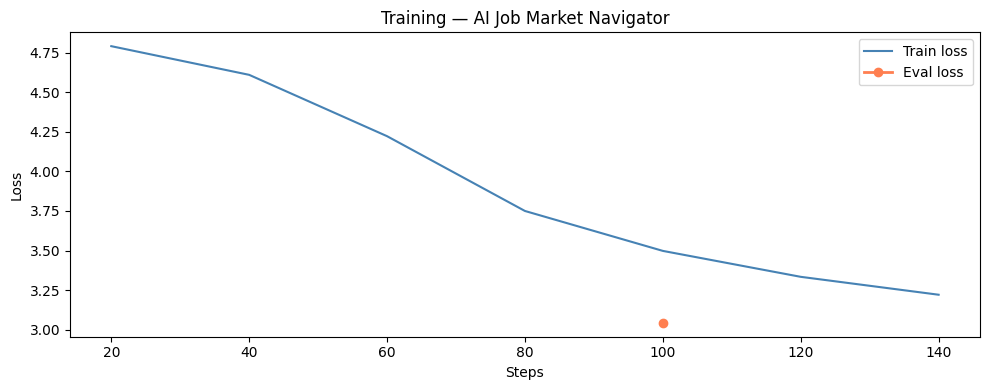

Final eval loss: 3.0429


In [13]:
# Cell 11 — Plot training loss
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_steps  = [x['step'] for x in logs if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss'] for x in logs if 'loss' in x and 'eval_loss' not in x]
eval_steps   = [x['step'] for x in logs if 'eval_loss' in x]
eval_losses  = [x['eval_loss'] for x in logs if 'eval_loss' in x]

plt.figure(figsize=(10, 4))
plt.plot(train_steps, train_losses, label='Train loss', color='steelblue', linewidth=1.5)
plt.plot(eval_steps, eval_losses, label='Eval loss', color='coral', linewidth=2, marker='o')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training — AI Job Market Navigator')
plt.legend()
plt.tight_layout()
plt.savefig('training_loss.png', dpi=120)
plt.show()

print(f'Final eval loss: {eval_losses[-1]:.4f}')

In [14]:
# Cell 12 — Push model to HuggingFace Hub
model.save_pretrained('./job-market-model-final')
tokenizer.save_pretrained('./job-market-model-final')

model.push_to_hub(MODEL_SAVE_NAME)
tokenizer.push_to_hub(MODEL_SAVE_NAME)

print(f'\n✅ Model saved to HuggingFace Hub!')
print(f'🔗 https://huggingface.co/{MODEL_SAVE_NAME}')
print('\nNext: Notebook 2 — RAG index builder ➡️')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########|  591kB /  591kB            

README.md: 0.00B [00:00, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.



✅ Model saved to HuggingFace Hub!
🔗 https://huggingface.co/kashanikram/job-market-navigator-distilgpt2

Next: Notebook 2 — RAG index builder ➡️


In [15]:
# Cell 13 — Quick inference test
from transformers import pipeline

generator = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    device=0
)

test_queries = [
    '### Instruction:\nWhat skills are needed for a Data Scientist role?\n\n### Response:\n',
    '### Instruction:\nWhat are requirements for a Software Engineer at Google?\n\n### Response:\n',
]

print('=== Inference Test ===\n')
for query in test_queries:
    output = generator(
        query,
        max_new_tokens=80,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id
    )
    resp = output[0]['generated_text'].split('### Response:\n')[-1].split('### End')[0].strip()
    question = query.split('\n')[1]
    print(f'Q: {question}')
    print(f'A: {resp[:200]}')
    print('-' * 50)

Passing `generation_config` together with generation-related arguments=({'top_p', 'max_new_tokens', 'do_sample', 'pad_token_id', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Inference Test ===



Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What skills are needed for a Data Scientist role?
A: {
 {
 {
 { "Core Responsibilities": "Create, update, and update datasets with new and updated datasets. Create, update and update datasets with new and updated datasets. Create, update and update data
--------------------------------------------------
Q: What are requirements for a Software Engineer at Google?
A: "Core Responsibilities": "Responses to maintain, maintain, and maintain Google products and services, maintain, maintain, and maintain Google products and services, maintain, maintain, and maintain Go
--------------------------------------------------
